# `pyspark`: Predict Flight Delays Using Machine Learning

* Machine learning enables us to teach computers to understand and make use of the insight they provide.
* Flight delays create problems in scheduling, passenger incovenience, and productivity losses. For that reason, there is interest in understanding what factors lead to delayed flights and predicting which flights are most likely to get delayed.
* In the form of MLlib, Spark provides a powerful library that can be used to predict flight delays
* Classification is a family of supervised machine learning algorithms that can be used to identify which category an item belongs to
  - Classification algorithms use "features" (inputs) and a "label" (desired target) to fit a trend through the available data

_The examples and case study in this notebook has been adapted from Chapter 5: Datasets, DataFrames, and Spark SQL of "Getting Started with Apache Spark" by Carol McDonald. The original examples were developed in Scala._

#### Environment Notes
This notebook includes setup code and options for working with data stored in MinIO (S3) using `pyspark` running in local mode.

### Spark and Storage Configuration

In [ ]:
import os, sys, posixpath

# User Options
USER_NAMESPACE = os.environ.get('HOSTNAME')

# Spark Options
SPARK_DRIVER_RAM = '3g'
SPARK_DRIVER_MAXRESULTSIZE = '4096m'
SPARK_WORKER_RAM = '6g'

# Access credentials for Object Storage
OBJECT_STORAGE_URL = os.environ.get('OBJECTS_ENDPOINT')
OBJECT_STORAGE_ACCESSID = os.environ.get('OBJECTS_ACCESSID')
OBJECT_STORAGE_SECRET = os.environ.get('OBJECTS_SECRET')
OBJECTS_PLAYGROUND_BUCKET = 'playground'
OBJECTS_USER_PREFIX = USER_NAMESPACE
OBJECT_CONTAINER = 'web-age'
STORAGEURL_PLAYGROUND = 'playground'

# Spark Runtime Options
os.environ['PYSPARK_PYTHON'] = 'python3'
os.environ['PYSPARK_DRIVER_PYTHON'] = 'python3'

In [ ]:
# Manage PySpark Runtime Options
PACKAGE_OPTIONS = '--packages %s ' % ','.join((        
        'com.amazonaws:aws-java-sdk:1.11.534',
        'com.amazonaws:aws-java-sdk-s3:1.11.534',
        'org.apache.hadoop:hadoop-aws:3.2.1',
        'io.delta:delta-core_2.12:1.0.0',
    ))

# JAR_OPTIONS = '--jars %s ' % ','.join((
#        '/opt/spark/jars/joda-time-2.9.9.jar',
#        '/opt/spark/jars/httpclient-4.5.3.jar',
#        '/opt/spark/jars/aws-java-sdk-s3-1.11.534.jar',
#        '/opt/spark/jars/aws-java-sdk-kms-1.11.534.jar',
#        '/opt/spark/jars/aws-java-sdk-dynamodb-1.11.534.jar',
#        '/opt/spark/jars/aws-java-sdk-core-1.11.534.jar',
#        '/opt/spark/jars/aws-java-sdk-1.11.534.jar',
#        '/opt/spark/jars/hadoop-aws-3.2.1.jar',
#        '/opt/spark/jars/slf4j-api-1.7.29.jar',
#        '/opt/spark/jars/slf4j-log4j12-1.7.29.jar',
#    ))

os.environ['PYSPARK_SUBMIT_ARGS'] = PACKAGE_OPTIONS + ' pyspark-shell'
os.environ.get('PYSPARK_SUBMIT_ARGS')

### Configure Spark for Local Context and Initialize `SparkContext` (Application Driver)

* `SparkSession` objects help to coordinate the components of a Spark program
  - When using the Spark shell, `SparkSession` objects are created automatically
  - For other programs (`spark-submit` and notebooks), they need to be created manually
* Spark running in cluster mode needs to communicate with a master, that manages the setup of drivers within a cluster computing system
  - Supported masters include Kubernetes, Mesosphere, and Hadoop
  - Example code below shows the initialization of a local master.

In [ ]:
import pyspark

conf = pyspark.SparkConf()

# Memory
conf.set('spark.driver.memory', SPARK_DRIVER_RAM)
conf.set("spark.executor.memory", SPARK_WORKER_RAM)
conf.set('spark.driver.maxResultSize', SPARK_DRIVER_MAXRESULTSIZE)

# The DNS alias for the Spark driver. Required by executors to report status.
conf.set("spark.driver.host", os.environ.get('HOSTNAME'))

# Port which the Spark shell should bind to and to which executors will report progress
conf.set("spark.driver.port", "20020")

# Configure S3 Object Storage as filesystem, pass MinIO credentials
conf.set("spark.hadoop.fs.s3a.endpoint", OBJECT_STORAGE_URL) \
    .set("spark.hadoop.fs.s3a.access.key", OBJECT_STORAGE_ACCESSID) \
    .set("spark.hadoop.fs.s3a.secret.key", OBJECT_STORAGE_SECRET) \
    .set("spark.hadoop.fs.s3a.fast.upload", True) \
    .set("spark.hadoop.fs.s3a.path.style.access", True) \
    .set("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")

# Configure Avro options
conf.set('avro.mapred.ignore.inputs.without.extension', 'true')

# Initialize spark context, create executors
conf.setAppName('local-arcos-extract-instructor')
sc = pyspark.SparkContext(conf=conf)

# Initialize Spark Session
from pyspark.sql import SparkSession
spark = SparkSession(sc)

Create a small distributed job to test the connection. _It's always a good idea to ensure that the context works and that worker nodes are able to communicate with the master._

In [ ]:
# Create a distributed data set to test to the session
t = sc.parallelize(range(10))

# Calculate the approximate sum of values in the dataset
r = t.sumApprox(3)
print('Approximate sum: %s' % r)

#### Import Visualization Tools

In [ ]:
import matplotlib
import seaborn as sns

%matplotlib inline

## U.S Flight Data
Data used in this notebook is available from the [United States Department of Transportation (DOT)](https://www.transtats.bts.gov/DL_SelectFields.asp?Table_ID=236&DB_Short_Name=On-Time). It has been deployed as JSON objects within MinIO (a storage solution that implements an interface similar to the one provided by Amazon's Simple Storage Solution - S3). _JSON is an example of a semi-structured form of data. It uses key/value paris to encode information and [includes support](https://www.json.org/json-en.html) for primitive types such as strings, arrays, numbers, booleans, and arrays._

The flight data includes the following fields:

* id: ID composed of carrier, date, origin, destination, flight number
* dofW: day of week (1=Monday, 7=Sunday)
* carrier: carrier code
* origin: origin airport code
* dest: destination airport code
* crsdephour: scheduled departure hour
* crsdeptime: scheduled departure time
* depdelay: departure delay in minutes
* crsarrtime: scheduled arrival time
* arrdelay: arrival delay minutes
* crselapsedtime: elapsed time
* dist: distance

Example:

```json
{
“_id”: “AA_2017-01-01_ATL_LGA_1678”,
“dofW”: 7,
“carrier”: “AA”,
“src”: “ATL”,
“dst”: “LGA”,
“crsdephour”: 17,
“crsdeptime”: 1700,
“depdelay”: 0.0,
“crsarrtime”: 1912,
“arrdelay”: 0.0,
“crselapsedtime”: 132.0,
“dist”: 762.0
}
```

## Machine Learning in Spark

* Considerations
* Algorithm Examples
* Workflow
* Spark ML Constructs

### Machine Learning Considerations
* What are we trying to predict?
  - Whether a flight will be delayed or not.
  - Outome label is "Delayed" and has a True or False value (binary classification)
  
* What are the properties that might be used to see if the flight is going to be delayed?
  - What is the originating airport?
  - What is the destination?
  - What is the scheduled time of departure?
  - What is the scheduled time of arrival?
  - What is the day of the week?
  - What is the airline carrier?

### Machine Learning Algorithms
There are many different algorithms that can be used to provide predictions.

* Decision trees create a model that predicts the label by evaluating a set of rules and answering a set of if-then-else questions.
* Ensemble methods (like Random Forests) combine multiple machine learning algorithsm to obtain a better model.
  - Random Forest creates many decision trees based on different subsets of data at the training stage
  - Predictions are made by combining the output from all the trees in the form of a "vote"
  - Combining output helps to reduce variance and improve the predictive accuracy

### Machine Learning Workflow
1. Data discovery and model creation
   - Analyze historical data
   - Identify data sources which might be used to address the question
   - Collect, correlate, and analyze data across the sources
   - Train, test, and evaluate the results of appropriate machine learning algorithms to build a model
2. Fine tune parameters to improve the accuracy of the model
3. Deploy to production and use the model to make predictions
4. Monitor the output of the model and consider updating if new data becomes avaialble or if the predictions are no longer accurate

### MLlib
To build a classifier model:

* Encode the outcome of interest
* Extract the features that contribute to the classification
* Package the features as a vector
* Train the model
* Evaluate the model 
* Iterate to find the best set of algorithms and contributors that provide the best estimates

#### Using Spark ML
Spark ML provides a set of APIs build on top of DataFrames.

* Being built on top of DataFrames allows training and evaluation to scale to large datasets
* Model preparation, training, and evaluation can be organized into pipelines to re-use
* Components
  - **Transformer**: Algorithm that transforms one DataFrame into another. Useful for creating a vector column for input into the model algorithm.
  - **Estimator**: Algorithm that can be fit on a DataFrame to produce a transformer. Used to train models, into which model can be input to get predictions.
  - **Pipeline**: Chains multiple transfomers and estimators into an ML workflow
  - **Evaluator**: Assess the accuracy of the model

## Load Data
* Retrieve from S3 (MinIO) and encode to a structured format

In [ ]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
import pyspark.sql.functions as sparkfunc
from pyspark.sql import DataFrameStatFunctions as statfunc

In [ ]:
# Create schema for the flight data
flights_schema = StructType([
    StructField('id', StringType(), True),
    StructField('month', IntegerType(), True),
    StructField('dofW', IntegerType(), True),
    StructField('carrier', StringType(), True),
    StructField('src', StringType(), True),
    StructField('dst', StringType(), True),
    StructField('crsdephour', IntegerType(), True),
    StructField('crsdeptime', DoubleType(), True),
    StructField('crsarrtime', DoubleType(), True),
    StructField('crselapsedtime', DoubleType(), True),
    StructField('depdelay', DoubleType(), True),
    StructField('dist', DoubleType(), True),
    
    # Fields used later for machine learning
    StructField('label', DoubleType(), True),
    StructField('pred_dtree', DoubleType(), True),
])

In [ ]:
# Load data from JSON and impose data
flights_df = spark.read.format('json') \
    .option('inferSchema', False) \
    .schema(flights_schema) \
    .load('s3a://web-age/wa2843/dot.flights.2018.json')

# Inspect data structure
flights_df.printSchema()

In [ ]:
# View data
flights_df.select('month', 'dofW', 'carrier', 'src', 'dst', 'depdelay', 'dist').show()

## Feature Engineering
Within the base features of a dataset there is often additional information that can be extracted and transformed to provide more context or detail. Refining the available data is called feature engineering.

* `route`: Combination of the source and destination of the plane

In [ ]:
# Create "route" column
flights_df = flights_df.withColumn(
    'route', sparkfunc.concat(
        sparkfunc.col('src'), sparkfunc.lit('-'), sparkfunc.col('dst')))

# View results of the transform
flights_df.printSchema()

In [ ]:
# Preview data
flights_df.select(
        'month', 'dofW', 'carrier', 'src', 'dst', 'crsdephour', 'crsdeptime', 'depdelay', 'dist', 'route')\
    .show()

## Encoding Outcome Data
Classification models need a defined outcome/label that is used in their training.

* Label: `delayed` (Boolean Value)
  - Delayed = 0 if the flight is on time
  - Delayed = 1 if the flight was more than forty minutes behind schedule
* Spark provides a "[Bucketizer](https://spark.apache.org/docs/2.2.0/ml-features.html#bucketizer)" which can be used to split data into labeled categories
  - "Bucketizer transforms a column of continuous features to a column of buckets, where the buckets are specified by the user"
    + `splits`: Parameter for mapping continuous features into buckets

In [ ]:
from pyspark.ml.feature import Bucketizer

In [ ]:
# Split the dataset into "delayed" and "on-time" groups based on the value of `depdelay`
flights_bucketizer = Bucketizer(
    splits=[-float('inf'), 40, float('inf')],
    inputCol='depdelay', outputCol='delayed')

In [ ]:
# Apply the splits to the dataset
flights_df = flights_bucketizer.transform(flights_df)
flights_df.printSchema()

In [ ]:
# Visualize the results of the transform
flights_df.select('month', 'dofW', 'carrier', 'dist', 'depdelay', 'delayed').show()

### Create Training and Testing Datasets

#### Visualize the Distribution By Outcome Label

In [ ]:
# Visualize the number of delayed flights to understand the distribution of the data
flights_delayed_pdf = flights_df.groupBy('crsdephour', 'delayed') \
    .agg(sparkfunc.count('id').alias('flight_count')).toPandas()

ax = sns.catplot(x='crsdephour', y='flight_count', hue='delayed', 
    kind='bar', data=flights_delayed_pdf, height=8, palette='muted')
ax.despine(left=True)
ax.set(xlabel='Hour of Flight Departure')
ax.set_ylabels('Number of Flights')

#### Unbalanced/Sparse Distributions
* The number of delayed flights is much smaller than the number of on-time flights.
  - In "unbalanced" or "sparse" distributions where one target is much more frequent than other targets, some machine learning algorithms will do a poor job classifying unless care is taken.
  - One option: include a higher percentage of the sparse label when creating the datasets that will be used for training. This is called **stratified sampling.**

In [ ]:
# Create a statified sample to use in training the machine learning model.
# The code below downsamples the number of on-time flights so that the 
# model will be more sensitive to the prediction of delayed flights
flights_strain = flights_df.sampleBy('delayed', { 0.0: 0.15, 1.0: 1.0 }, 36)
flights_training, flights_testing = flights_strain.randomSplit([0.7, 0.3], 44)

In [ ]:
# Inspect the results of the split
flights_strain.groupBy('delayed').count().show()

## Train and Test a Model

#### Creating Pipeline Components Required to Train the Model

* A pipeline is a set of steps that are executed in a workflow.
  - When working with big data, a set of steps will often be composed and executed in a single queue because there can be (sometimes significant) delay while waiting for processing jobs to finish.
* Pipelines are important in Spark machine learning workflows.

In [ ]:
from pyspark.ml import Pipeline

* To train and fit a model, we need to create a "label" and "feature" vector and add them to the data frame
* Most machine learning algorithms require numeric input data in order to work correctly
  - Utilize a `StringIndexer` to handle the data transform
  - Indexing categorical variables can be done as part of a larger pipeline

In [ ]:
# Categorical fields which should be transformed
categorical_columns = ('carrier', 'src', 'dst', 'dofW', 'route')

In [ ]:
from pyspark.ml.feature import StringIndexer
from collections import OrderedDict

# Create string indexer instances to take categorical string data into indexed numerical labels.
# The resulting processing steps are saved into an ordered dict so they can be passed into a 
# pipeline.
string_indexers = OrderedDict((c, StringIndexer(inputCol=c, outputCol=c+'_index', ).fit(flights_strain))
    for c in categorical_columns)

In [ ]:
string_indexers

* `VectorAssembler` is a component that is use to compose a set of features into a structure that can be given to Spark's machine learning algorithms.

In [ ]:
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler

In [ ]:
# Create a Vector Assembler that will combine all desired features into a single input "vector"
# for the machine learning algorithm to be used later
flights_assembler = VectorAssembler(outputCol='features',
    inputCols=[c+'_index' for c in categorical_columns]
        +['crsdephour', 'crsdeptime', 'crsarrtime', 'crselapsedtime', 'dist'])

#### Configure a Machine Learning Algorithm
* Final element in the pipeline is to create an "estimator" or machine learning algorithm that train on the input data (vector of features and labels)
* The "estimator" returns a "transformer" model

In [ ]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [ ]:
# Configure the random forest classifier
flights_rf = RandomForestClassifier(
    labelCol='delayed', featuresCol='features', numTrees=10, maxBins=150)

#### Chain the Components of the Pipeline
The pipeline created above has the following components:

* A set of string indexers that will work on the categorical columns (five in total)
* A vector assembler that takes the encoded columns and other continuous data and combines it into a features vector
* The random forest estimator that will be trained on the data from the pipeline

In [ ]:
# Combine all components into a single process
flights_pipeline = Pipeline(stages=list(string_indexers.values())+[flights_assembler, flights_rf])

### Train the Model


In [ ]:
# Create a random forest training instance from the pipeline
flights_model1 = flights_pipeline.fit(flights_training)

### Apply the Model

In [ ]:
# Utilize the model instance to create a dataframe with predictions
flights_predictions1 = flights_model1.transform(flights_testing)

# Show relevant output colums
flights_predictions1.select('month', 'dofW', 'carrier', 'src', 'dst', 'route',  
    'probability', 'prediction', 'delayed').show()

### Assess the Model
* In Spark "evaluators" are used to determine the performance of a model
* For binary classification, the evaulators measure the accuracy of the model by using a ROC curve
  - Area under the curve (AUC) measures the ability of the test to correctly classify true positives from false positives
  - A random predictor would have 0.5 (it is possible to be worse than random)
  - Closer a curve comes to 1, the better the predictions

In [ ]:
# In Spark "evaluators" are used to determine the performance of a model
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [ ]:
# Create an evaulator instance to check the accuracy of the predictions
flights_evalutor1 = BinaryClassificationEvaluator(labelCol='delayed')
print('Accuracy of Random Forest (Attempt 1 ROC): %s' % flights_evalutor1.evaluate(flights_predictions1))

## Refine the Model
As part of the model training process, it's often desired to test multiple different models in order to find a set of parameters that produce the best performance. (This is sometimes called hyperparameter tuning.)

* Hyperparameter tuning can be accomplished through a formal evaluation process
* Common technique for model training and evaluation (called cross validation) is k-folds cross validation
  - In k-folds data is randomly split into a set of partitions (k in total)
  - Each partition is used once as the testing data set while the rest are used for training
  - Models are generated with the training sets and evaluated with the testing sets
* Spark supports k-fold cross validation and can utilize a transformation/estimation pipeline to tryout combinations of parameters
  - Process used to search through various sets of parametrs is called a "grid search"
  - In a grid search, various parameters are set up and Spark searches through the grid for the model which provides the best performance

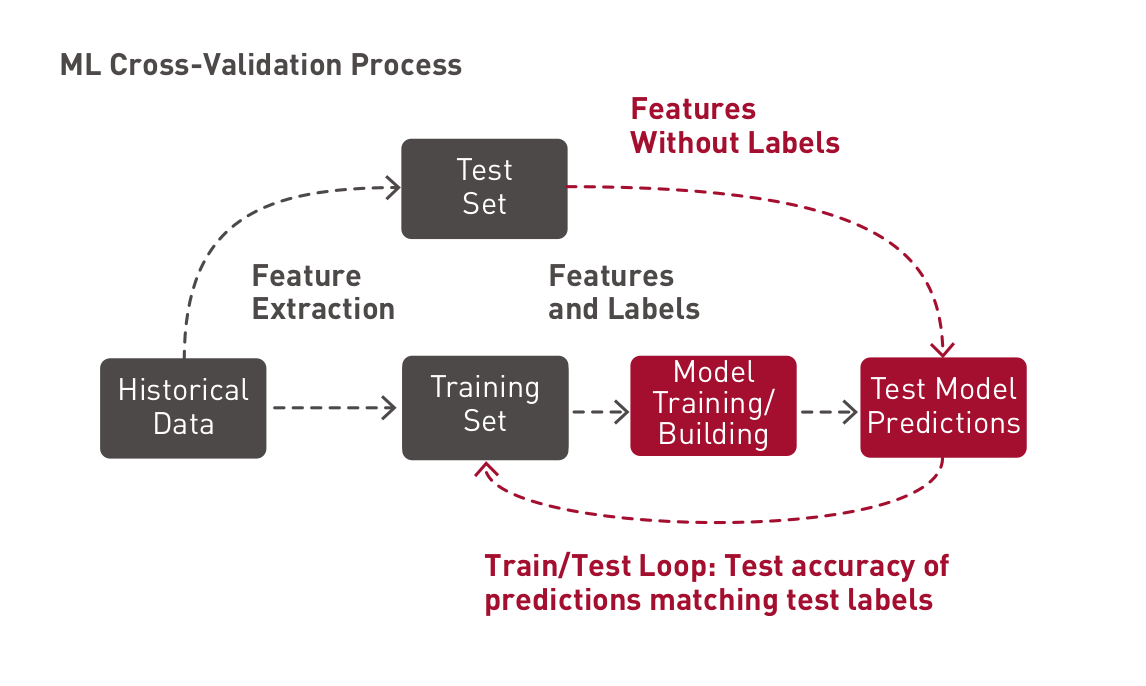

In [ ]:
# ParamGridBuilder creates the set of parameters over which the system should iterate 
# to find the best model fit
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

In [ ]:
# ParamGridBuilder will look through a number of different options that are specific to random 
# forests. For more information on what the options do, see the Spark documentation.
# https://spark.apache.org/docs/latest/ml-classification-regression.html#random-forests
flights_paramgrid = ParamGridBuilder() \
    .addGrid(flights_rf.maxBins, [150, 200]) \
    .addGrid(flights_rf.maxDepth, [2, 4, 10]) \
    .addGrid(flights_rf.numTrees, [5, 20]) \
    .addGrid(flights_rf.impurity, ["entropy", "gini"]) \
    .build()

In [ ]:
# Evaluator assesses the behavior of the model by comparing the test label column with
# the test prediction column
flights_evaluator2 = BinaryClassificationEvaluator(labelCol='delayed')

In [ ]:
# Create a cross validator instance that incorporates the grid search
flights_crossval = CrossValidator(estimator=flights_pipeline,
    estimatorParamMaps=flights_paramgrid, evaluator=flights_evaluator2, numFolds=3) 

In [ ]:
# Fit the training data set and return a trained model
flights_rfmodel2 = flights_crossval.fit(flights_training)

#### Inspect Model for the Importance of Features
With many classical machine learning techniques, it is possible to inspect models to understand which features contribute most to the behavior of the model.

In [ ]:
# Unpack the pipeline model to find the random forest predictor
flights_fweights = flights_rfmodel2.bestModel \
    .stages[len(string_indexers)+1] \
    .featureImportances

In [ ]:
# Associate the feature importances with its associated column
flights_ofweights = sorted(
    [(f, flights_fweights[i]) for i,f in enumerate(flights_assembler.getInputCols())],
    key=lambda w: -w[1])

for fweight in flights_ofweights:
    print('feature: %s, importance: %s' % fweight)

### Assess the Tuned Model

In [ ]:
flights_predictions2 = flights_rfmodel2.transform(flights_testing)
flights_predictions2.select('month', 'dofW', 'carrier', 'src', 'dst', 'route',  
    'probability', 'prediction', 'delayed').show()

In [ ]:
flights_evalutor2 = BinaryClassificationEvaluator(labelCol='delayed')
print('Accuracy of Random Forest (Attempt 2 ROC): %s' % flights_evalutor2.evaluate(flights_predictions2))

## Exporting a Model
* Spark provides support for exporting models to an external location
  - This example uses S3 object storage
* Models are saved by calling `model.write().save('s3a://bucket/filekey')`

### Saving a Model

In [ ]:
# Save Model to Object Storage
flights_rfmodel2.bestModel.write().overwrite().save('s3a://playground/flights-dot.rf-classifier.smodel')

### Loading a Model

In [ ]:
from pyspark.ml import PipelineModel
from pyspark.ml.tuning import CrossValidatorModel

In [ ]:
flights_frmodel_s3 = PipelineModel.load('s3a://playground/flights-dot.rf-classifier.smodel')